# Сборка единого датасета под Задачу 1 (табличные данные)

Третий ноутбук конвейера. Из нарезанного среза (`data/processed/*.parquet`) собираем **один плоский
датасет** для рекомендательной полносвязной сети: предсказание оценки `stars`, которую пользователь
поставит заведению, по табличным признакам пользователя и заведения.

**Логика:** «позвоночник» — таблица `reviews` (1 строка = 1 отзыв = 1 пара пользователь×заведение
с известным таргетом). К ней слева подклеиваем признаки `business` (по `business_id`) и `users`
(по `user_id`).

```
reviews ──LEFT JOIN business ON business_id──┐
        └─LEFT JOIN users    ON user_id──────┴──► task1_dataset (target = stars)
```

Текст отзывов и таблица `tips` сюда НЕ входят — это сырьё Задачи 2.

In [1]:
import re
import sys
from pathlib import Path
import numpy as np
import pandas as pd
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(root))
from _constants import REVIEWS_PARQUET, BUSINESS_PARQUET, USERS_PARQUET, PROCESSED
TOPK = 20
OUT = PROCESSED / "task1_dataset.parquet"
SEED = 42

## 1. Загрузка таблиц среза

Из `reviews` берём только нужные колонки (текст и голоса отзыва не грузим — см. раздел 3 про
утечки). Сразу переименовываем колонки, которые иначе столкнулись бы при join
(`stars`, `review_count`, `useful/funny/cool` есть в нескольких таблицах).

In [2]:
cols = ["review_id", "user_id", "business_id", "stars", "date"]
reviews = pd.read_parquet(REVIEWS_PARQUET, columns=cols)
business = pd.read_parquet(BUSINESS_PARQUET)
business = business.drop(columns=["name", "postal_code", "city", "state"])
business = business.rename(columns={"stars": "biz_avg_stars", "review_count": "biz_review_count"})
users = pd.read_parquet(USERS_PARQUET)
users = users.rename(columns={"review_count": "user_review_count", "useful": "user_useful", "funny": "user_funny", "cool": "user_cool"})
print("reviews :", reviews.shape)
print("business:", business.shape)
print("users   :", users.shape)

reviews : (664751, 5)
business: (17556, 9)
users   : (209093, 10)


## 2. Объединение в один датасет

`reviews` — левая таблица, гранулярность сохраняется (1 строка = 1 отзыв).

In [3]:
df = reviews.merge(business, on="business_id", how="left")
df = df.merge(users, on="user_id", how="left")
print("Объединённый датасет:", df.shape)
assert len(df) == len(reviews)
before = len(df)
df = df.dropna(subset=["average_stars"]).reset_index(drop=True)
print(f"Удалено строк без профиля пользователя: {before - len(df)}")
df.head(3)

Объединённый датасет: (664751, 22)
Удалено строк без профиля пользователя: 6


,review_id,user_id,business_id,stars,date,city_state,latitude,longitude,biz_avg_stars,biz_review_count,...,price_range,user_review_count,yelping_since,user_useful,user_funny,user_cool,fans,average_stars,n_friends,n_elite_years
0,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,"Tucson, AZ",32.207233,-110.980864,3.5,47,...,1.0,1332.0,2012-09-04 23:57:25,1660.0,675.0,1300.0,58.0,4.69,119.0,9.0
1,UBp0zWyH60Hmw6Fsasei7w,4Uh27DgGzsp6PqrH913giQ,otQS34_MymijPTdNBoBdCw,4.0,2011-10-27 17:12:05,"Tucson, AZ",32.255834,-110.960560,4.0,492,...,2.0,50.0,2009-09-29 22:24:04,146.0,106.0,77.0,2.0,4.27,40.0,2.0
2,rV6AWGN4rYORMQY8dVP41g,dKoIp8vsKFH4cbmGSYy2IQ,0ICfbEImE0gUZc4kSZ7QHg,5.0,2013-11-14 04:58:09,"Edmonton, AB",53.499624,-113.456746,2.5,27,...,NaN,11.0,2012-02-20 04:58:56,15.0,8.0,3.0,0.0,4.64,0.0,0.0


## 3. Чистка утечек и инжиниринг признаков

**Утечки таргета** уже исключены тем, что мы не грузили `text` и `review.useful/funny/cool`
(они известны только ПОСЛЕ написания отзыва). Дополнительно:

- `account_age_days` — стаж пользователя на момент отзыва (`date − yelping_since`);
- `price_range` пуст у ~44% заведений → флаг `price_known` + импутация медианой;
- `user_avg_minus_biz` — насколько пользователь в среднем строже/добрее среднего по заведению.

> Замечание: `biz_avg_stars`, `biz_review_count`, `average_stars` — агрегаты по всем отзывам
> (мягкая утечка). Поэтому ниже делаем **временной** train/val/test-сплит по дате.

In [4]:
df["date"] = pd.to_datetime(df["date"])
df["yelping_since"] = pd.to_datetime(df["yelping_since"])
df["account_age_days"] = (df["date"] - df["yelping_since"]).dt.days.clip(lower=0)
df["price_known"] = df["price_range"].notna().astype(int)
df["price_range"] = df["price_range"].fillna(df["price_range"].median())
df["user_avg_minus_biz"] = df["average_stars"] - df["biz_avg_stars"]
df = df.drop(columns=["yelping_since"])

## 4. Кодирование категориальных признаков

- `categories` — мульти-метка: одно заведение принадлежит нескольким категориям. Кодируем
  **multi-hot** по топ-K самых частых категорий среза (`cat_*`).
- `city_state` — всего 3 города → one-hot (`city_*`).

In [5]:
cat_sets = df["categories"].fillna("").apply(lambda s: {x.strip() for x in s.split(",") if x.strip()})
top_cats = df["categories"].dropna().str.split(", ").explode().value_counts().head(TOPK).index.tolist()
def slug(name):
    return "cat_" + re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")
for cat in top_cats:
    df[slug(cat)] = cat_sets.apply(lambda st: int(cat in st))
cat_cols = [slug(c) for c in top_cats]
city_oh = pd.get_dummies(df["city_state"], prefix="city").astype(int)
df = pd.concat([df, city_oh], axis=1)
city_cols = city_oh.columns.tolist()
df = df.drop(columns=["categories", "city_state"])
print(f"Категорий multi-hot: {len(cat_cols)} | городов one-hot: {len(city_cols)}")
print("Топ-категории:", top_cats[:8], "...")

Категорий multi-hot: 20 | городов one-hot: 3
Топ-категории: ['Restaurants', 'Food', 'Nightlife', 'Bars', 'American (Traditional)', 'Breakfast & Brunch', 'American (New)', 'Mexican'] ...


## 5. Временной train/val/test-сплит

Делим по `date` (70% / 15% / 15%): учимся на прошлом, проверяем на будущем — так агрегатные
признаки не «подсматривают» будущее.

In [6]:
df = df.sort_values("date").reset_index(drop=True)
q70, q85 = df["date"].quantile([0.70, 0.85])
df["split"] = np.where(df["date"] <= q70, "train", np.where(df["date"] <= q85, "val", "test"))
print(df["split"].value_counts(normalize=True).round(3).to_dict())
print("границы:", q70.date(), q85.date())

{'train': 0.7, 'val': 0.15, 'test': 0.15}
границы: 2019-01-18 2020-04-23


## 6. Сохранение готового датасета

Итог — один parquet: ключи (для справки), `date`, `split`, таргет `stars` и табличные признаки.

In [7]:
PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUT, index=False)
id_cols = ["review_id", "user_id", "business_id"]
num_cols = ["biz_avg_stars", "biz_review_count", "is_open", "price_range", "price_known",
            "latitude", "longitude", "user_review_count", "average_stars",
            "user_useful", "user_funny", "user_cool", "fans", "n_friends",
            "n_elite_years", "account_age_days", "user_avg_minus_biz"]
feature_cols = num_cols + cat_cols + city_cols
print(f"[ok] {OUT.name}: {df.shape[0]:,} строк, {df.shape[1]} колонок")
print(f"  таргет: stars | признаков: {len(feature_cols)} "
      f"({len(num_cols)} числовых + {len(cat_cols)} категорий + {len(city_cols)} городов)")
print(f"  служебные (не признаки): {id_cols + ['date', 'split']}")
print("\nПризнаки:")
for col in feature_cols:
    print("  -", col)

[ok] task1_dataset.parquet: 664,745 строк, 46 колонок
  таргет: stars | признаков: 40 (17 числовых + 20 категорий + 3 городов)
  служебные (не признаки): ['review_id', 'user_id', 'business_id', 'date', 'split']

Признаки:
  - biz_avg_stars
  - biz_review_count
  - is_open
  - price_range
  - price_known
  - latitude
  - longitude
  - user_review_count
  - average_stars
  - user_useful
  - user_funny
  - user_cool
  - fans
  - n_friends
  - n_elite_years
  - account_age_days
  - user_avg_minus_biz
  - cat_restaurants
  - cat_food
  - cat_nightlife
  - cat_bars
  - cat_american_traditional
  - cat_breakfast_brunch
  - cat_american_new
  - cat_mexican
  - cat_shopping
  - cat_sandwiches
  - cat_event_planning_services
  - cat_pizza
  - cat_beauty_spas
  - cat_burgers
  - cat_coffee_tea
  - cat_italian
  - cat_cocktail_bars
  - cat_seafood
  - cat_salad
  - cat_home_services
  - city_Edmonton, AB
  - city_St Petersburg, FL
  - city_Tucson, AZ


## 7. Корреляционный анализ

Смотрим линейную связь признаков с таргетом `stars` и между собой (Pearson).
Считаем **только на train** — чтобы не подглядывать в val/test. Цель — понять, какие признаки
несут сигнал, а какие дублируют друг друга (мультиколлинеарность).

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from _constants import ARTIFACTS, ENABLE_ARTIFACTS
sns.set_theme(style="whitegrid")
train = df[df["split"] == "train"]
corr = train[feature_cols + ["stars"]].corr(method="pearson")
target_corr = corr["stars"].drop("stars").sort_values(ascending=False)
print("Корреляция признаков с таргетом stars (Pearson, train):")
for name, val in target_corr.items():
    print(f"  {val:+.3f}  {name}")

Matplotlib is building the font cache; this may take a moment.


Корреляция признаков с таргетом stars (Pearson, train):
  +0.552  average_stars
  +0.477  biz_avg_stars
  +0.110  biz_review_count
  +0.105  user_avg_minus_biz
  +0.063  account_age_days
  +0.059  cat_food
  +0.057  n_elite_years
  +0.052  longitude
  +0.050  is_open
  +0.049  city_St Petersburg, FL
  +0.048  n_friends
  +0.040  cat_breakfast_brunch
  +0.039  cat_coffee_tea
  +0.039  price_known
  +0.031  fans
  +0.029  user_review_count
  +0.028  cat_cocktail_bars
  +0.027  cat_american_new
  +0.024  cat_sandwiches
  +0.023  cat_beauty_spas
  +0.022  cat_restaurants
  +0.019  user_useful
  +0.018  user_cool
  +0.013  user_funny
  +0.013  cat_italian
  +0.011  cat_bars
  +0.010  cat_mexican
  +0.010  cat_nightlife
  +0.009  cat_salad
  +0.002  cat_pizza
  -0.001  city_Tucson, AZ
  -0.004  cat_seafood
  -0.005  cat_event_planning_services
  -0.011  cat_shopping
  -0.015  price_range
  -0.021  cat_american_traditional
  -0.035  cat_burgers
  -0.052  city_Edmonton, AB
  -0.052  cat_home_s

### 7.1. Корреляция с целевой переменной

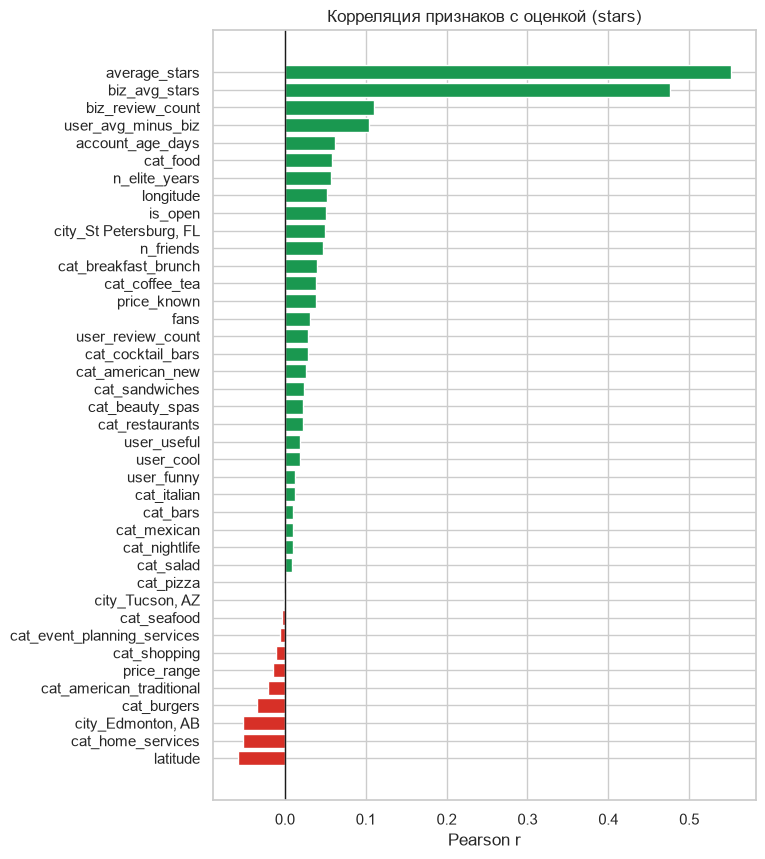

In [9]:
fig, ax = plt.subplots(figsize=(7, 10))
colors = ["#d73027" if v < 0 else "#1a9850" for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="k", lw=1)
ax.set_title("Корреляция признаков с оценкой (stars)")
ax.set_xlabel("Pearson r")
if ENABLE_ARTIFACTS:
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "task1_target_corr.png", dpi=140, bbox_inches="tight")
plt.show()

### 7.2. Матрица корреляций числовых признаков (мультиколлинеарность)

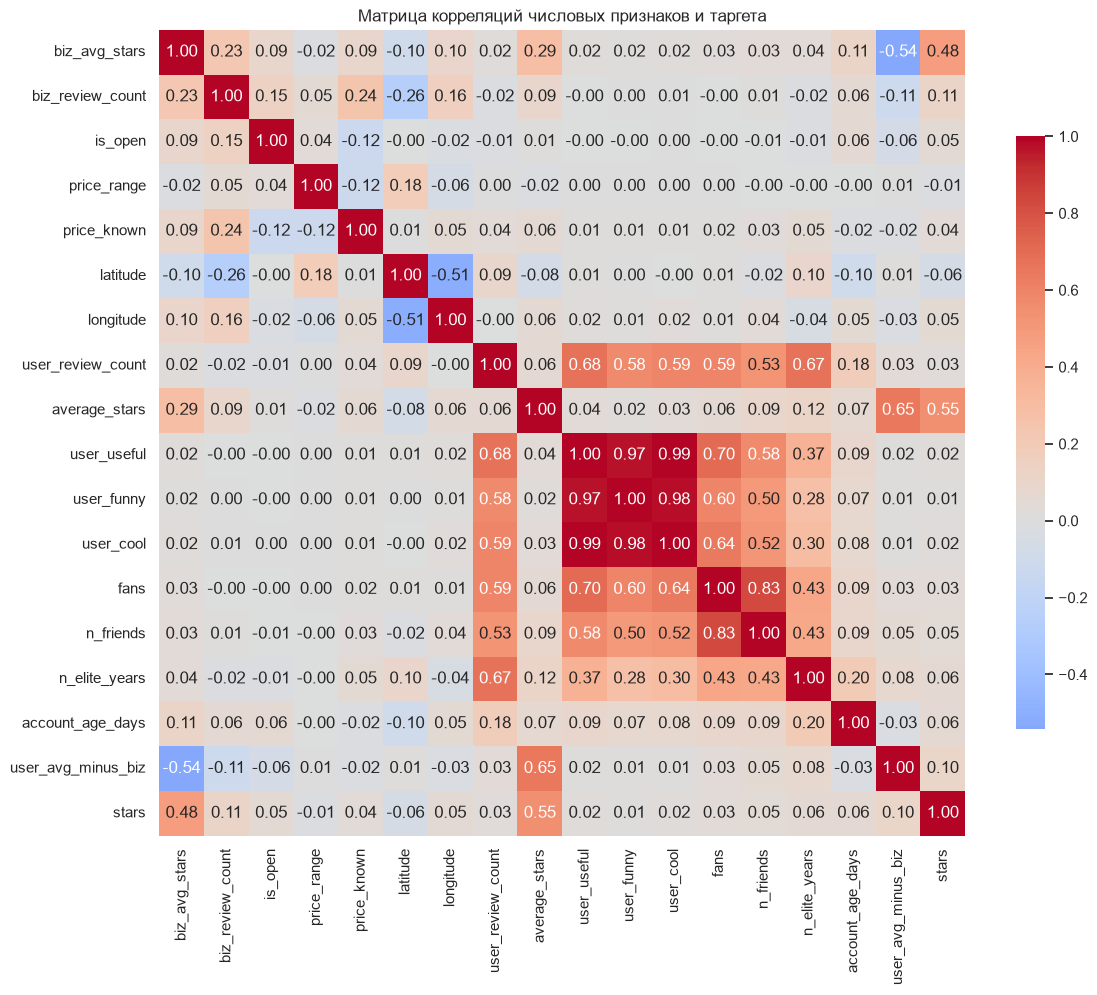

In [10]:
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(train[num_cols + ["stars"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Матрица корреляций числовых признаков и таргета")
if ENABLE_ARTIFACTS:
    plt.tight_layout()
    plt.savefig(ARTIFACTS / "task1_corr_matrix.png", dpi=140, bbox_inches="tight")
plt.show()

In [11]:
import numpy as np
cm = train[feature_cols].corr().abs()
mask = np.triu(np.ones(cm.shape), k=1).astype(bool)
pairs = cm.where(mask).stack().sort_values(ascending=False)
strong = pairs[pairs > 0.7]
print("Пары признаков с |r| > 0.7 (мультиколлинеарность):")
if len(strong) == 0:
    print("  нет пар выше порога")
for (a, b), v in strong.items():
    print(f"  {v:.3f}  {a} ~ {b}")

Пары признаков с |r| > 0.7 (мультиколлинеарность):
  0.997  longitude ~ city_St Petersburg, FL
  0.989  user_useful ~ user_cool
  0.979  latitude ~ city_Edmonton, AB
  0.976  user_funny ~ user_cool
  0.976  cat_nightlife ~ cat_bars
  0.966  user_useful ~ user_funny
  0.826  fans ~ n_friends
  0.703  user_useful ~ fans


## 8. Заведения с несколькими категориями

У Yelp поле `categories` — это список тегов, где смешаны «зонтичные» теги (Restaurants, Food,
Nightlife) и конкретные кухни (Mexican, Italian, …). Здесь смотрим два вопроса:

1. насколько вообще заведения мультикатегориальны;
2. сколько заведений сочетают **несколько разных кухонь одновременно** (напр. мексиканская +
   итальянская) — и какие пары кухонь встречаются вместе чаще всего.

In [12]:
from collections import Counter
from itertools import combinations
import pandas as pd
from _constants import BUSINESS_PARQUET
biz_cat = pd.read_parquet(BUSINESS_PARQUET, columns=["business_id", "categories"])
cat_lists = biz_cat["categories"].fillna("").apply(lambda s: [c.strip() for c in s.split(",") if c.strip()])
n_cat = cat_lists.apply(len)
print(f"Всего заведений: {len(biz_cat):,}")
print(f"Среднее число категорий на заведение: {n_cat.mean():.2f} (медиана {int(n_cat.median())}, макс {n_cat.max()})")
print(f"С >= 2 категориями: {(n_cat >= 2).sum():,} ({(n_cat >= 2).mean():.1%})")
print(f"Ровно с 1 категорией: {(n_cat == 1).sum():,} | без категорий: {(n_cat == 0).sum():,}")
print("\nРаспределение числа категорий:")
print(n_cat.value_counts().sort_index().head(8).to_string())

Всего заведений: 17,556
Среднее число категорий на заведение: 4.32 (медиана 4, макс 25)
С >= 2 категориями: 17,490 (99.6%)
Ровно с 1 категорией: 56 | без категорий: 10

Распределение числа категорий:
categories
0      10
1      56
2    4105
3    3298
4    2993
5    2709
6    1818
7    1153


### 8.1. Мульти-кухонные заведения

Берём только **национальные/этнические кухни** (Mexican, Italian, Chinese, …) — это то, что
обычно понимают под «кухней». Зонтичные теги (Restaurants, Food, Bars) и форматы блюд
(Pizza, Burgers) сюда не входим. Считаем заведения, у которых таких кухонь **две и более**.

In [13]:
CUISINES = {
    "Mexican", "Italian", "Chinese", "Japanese", "Thai", "Indian", "Vietnamese", "Korean",
    "Mediterranean", "Greek", "French", "Spanish", "Middle Eastern", "American (Traditional)",
    "American (New)", "Latin American", "Caribbean", "Cuban", "Asian Fusion", "Tex-Mex",
    "Cajun/Creole", "Southern", "Filipino", "Hawaiian", "German", "Irish", "British",
    "Lebanese", "Turkish", "Ethiopian", "Peruvian", "Brazilian", "Portuguese", "Pakistani",
    "Persian/Iranian", "Halal", "Soul Food", "Taiwanese", "Mongolian", "Afghan",
}
cuisine_lists = cat_lists.apply(lambda lst: [c for c in lst if c in CUISINES])
n_cuisine = cuisine_lists.apply(len)
is_food = cat_lists.apply(lambda lst: ("Restaurants" in lst) or ("Food" in lst))
n_food = int(is_food.sum())
multi = n_cuisine >= 2
print(f"Заведений общепита (Restaurants/Food): {n_food:,}")
print(f"С указанной хотя бы 1 кухней: {(n_cuisine >= 1).sum():,}")
print(f"С >= 2 разными кухнями одновременно: {multi.sum():,} "
      f"({multi.sum()/n_food:.1%} от общепита, {multi.mean():.1%} от всех заведений)")
print(f"Максимум кухонь у одного заведения: {n_cuisine.max()}")
print("\nРаспределение числа кухонь (среди заведений с >= 1 кухней):")
print(n_cuisine[n_cuisine >= 1].value_counts().sort_index().to_string())

Заведений общепита (Restaurants/Food): 7,030
С указанной хотя бы 1 кухней: 3,469
С >= 2 разными кухнями одновременно: 779 (11.1% от общепита, 4.4% от всех заведений)
Максимум кухонь у одного заведения: 6

Распределение числа кухонь (среди заведений с >= 1 кухней):
categories
1    2690
2     628
3     123
4      24
5       3
6       1


### 8.2. Самые частые пары кухонь

In [14]:
pair_counter = Counter()
for lst in cuisine_lists:
    for a, b in combinations(sorted(set(lst)), 2):
        pair_counter[(a, b)] += 1
print("Топ-15 совместно встречающихся пар кухонь:")
for (a, b), cnt in pair_counter.most_common(15):
    print(f"  {cnt:>4}  {a} + {b}")

Топ-15 совместно встречающихся пар кухонь:
   146  American (New) + American (Traditional)
    61  Mexican + Tex-Mex
    57  Asian Fusion + Chinese
    43  Mediterranean + Middle Eastern
    40  Greek + Mediterranean
    35  Asian Fusion + Japanese
    31  Chinese + Vietnamese
    29  American (Traditional) + Mexican
    27  Latin American + Mexican
    23  Indian + Pakistani
    23  Chinese + Thai
    21  Lebanese + Middle Eastern
    19  Chinese + Japanese
    18  American (New) + Mexican
    17  Asian Fusion + Thai


## 9. Подготовка данных для entity embeddings

Для эмбеддингов категории кодируются НЕ one-hot, а целочисленными индексами (сеть сама превратит
индекс в обучаемый вектор). Готовим второй вариант входа:

- словари индексов строятся **только на train** (0 зарезервирован под `<pad>/<unknown>`/OOV);
- `categories` — мультилейбл → список индексов с паддингом до фиксированной длины (пулинг в модели);
- `city_state`, `business_id` — одиночные индексы;
- числовые признаки — `log1p` (скошенные) + `StandardScaler` (fit на train);
- все мэппинги и scaler сохраняем в `artifacts/` (воспроизводимый инференс, Критерий 5).

`latitude/longitude` и `user_id` не используем: первые дублируют город (секция 7),
второй — холодный старт (61% юзеров с 1 отзывом).

In [15]:
import json
from collections import Counter
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from _constants import PROCESSED, BUSINESS_PARQUET, ARTIFACTS
MIN_CAT_FREQ = 20
MAXLEN = 10
cols = ["review_id", "business_id", "split", "stars",
        "biz_avg_stars", "biz_review_count", "is_open", "price_range", "price_known",
        "user_review_count", "average_stars", "user_useful", "user_funny", "user_cool",
        "fans", "n_friends", "n_elite_years", "account_age_days", "user_avg_minus_biz"]
emb = pd.read_parquet(PROCESSED / "task1_dataset.parquet")[cols].copy()
biz = pd.read_parquet(BUSINESS_PARQUET, columns=["business_id", "categories", "city_state"])
biz["cat_list"] = biz["categories"].fillna("").apply(lambda s: [x.strip() for x in s.split(",") if x.strip()])
emb = emb.merge(biz[["business_id", "cat_list", "city_state"]], on="business_id", how="left")
train_mask = emb["split"] == "train"
print("Строк:", len(emb), "| train:", int(train_mask.sum()))

Строк: 664745 | train: 465321


### 9.1. Словари индексов (fit только на train)

In [16]:
train = emb[train_mask]
train_biz_ids = set(train["business_id"])
train_biz = biz[biz["business_id"].isin(train_biz_ids)]
freq = Counter(c for lst in train_biz["cat_list"] for c in lst)
kept = sorted([c for c, v in freq.items() if v >= MIN_CAT_FREQ])
cat_vocab = {c: i + 1 for i, c in enumerate(kept)}
city_vocab = {c: i + 1 for i, c in enumerate(sorted(train["city_state"].dropna().unique()))}
biz_vocab = {b: i + 1 for i, b in enumerate(sorted(train["business_id"].unique()))}
print(f"Словарь категорий: {len(cat_vocab)} (из {len(freq)} уникальных, порог частоты {MIN_CAT_FREQ})")
print(f"Словарь городов:   {len(city_vocab)}")
print(f"Словарь заведений: {len(biz_vocab)}")
def emb_dim(card):
    return int(min(50, round(1.6 * card ** 0.56)))
print("\nРекомендуемые размерности эмбеддингов:")
print(f"  city  ({len(city_vocab)+1:>6}) -> {emb_dim(len(city_vocab)+1)}")
print(f"  cats  ({len(cat_vocab)+1:>6}) -> {emb_dim(len(cat_vocab)+1)}")
print(f"  biz   ({len(biz_vocab)+1:>6}) -> {emb_dim(len(biz_vocab)+1)}")

Словарь категорий: 423 (из 1099 уникальных, порог частоты 20)
Словарь городов:   3
Словарь заведений: 16339

Рекомендуемые размерности эмбеддингов:
  city  (     4) -> 3
  cats  (   424) -> 47
  biz   ( 16340) -> 50


### 9.2. Кодирование в индексы (+ паддинг мультилейбла)

In [17]:
# !!!!!!!! COLD-START: холодный старт / OOV !!!!!!!!
def encode_cats(lst):
    ids = [cat_vocab[c] for c in (lst or []) if c in cat_vocab][:MAXLEN]
    return ids + [0] * (MAXLEN - len(ids))
cat_mat = np.array(emb["cat_list"].apply(encode_cats).to_list(), dtype="int64")
emb["city_idx"] = emb["city_state"].map(city_vocab).fillna(0).astype("int64")
emb["biz_idx"] = emb["business_id"].map(biz_vocab).fillna(0).astype("int64")
val_test = emb[emb["split"] != "train"]
print(f"OOV-заведений в val/test (холодный старт): {(val_test['biz_idx'] == 0).mean():.1%}")
no_cat = (emb['split'] != 'train').to_numpy()
print(f"Строк без единой известной категории в val/test: {(cat_mat[no_cat].sum(axis=1) == 0).mean():.1%}")
print("Пример закодированных категорий (первая строка):", cat_mat[0])

OOV-заведений в val/test (холодный старт): 14.7%
Строк без единой известной категории в val/test: 0.0%
Пример закодированных категорий (первая строка): [148 149 349 170 147   0   0   0   0   0]


### 9.3. Числовые признаки: log1p + StandardScaler (fit на train)

In [18]:
NUM = ["biz_avg_stars", "biz_review_count", "is_open", "price_range", "price_known",
       "user_review_count", "average_stars", "user_useful", "user_funny", "user_cool",
       "fans", "n_friends", "n_elite_years", "account_age_days", "user_avg_minus_biz"]
LOG = ["biz_review_count", "user_review_count", "user_useful", "user_funny",
       "user_cool", "fans", "n_friends"]
Xnum = emb[NUM].copy()
Xnum[LOG] = np.log1p(Xnum[LOG])
scaler = StandardScaler().fit(Xnum[train_mask.to_numpy()])
Xnum_scaled = pd.DataFrame(scaler.transform(Xnum), columns=["num_" + c for c in NUM])
print("Числовых признаков отмасштабировано:", len(NUM))
print("Проверка (train): среднее ~0, std ~1:",
      np.round(Xnum_scaled[train_mask.to_numpy()].mean().abs().max(), 4),
      np.round(Xnum_scaled[train_mask.to_numpy()].std().mean(), 3))

Числовых признаков отмасштабировано: 15


Проверка (train): среднее ~0, std ~1: 0.0 1.0


### 9.4. Сохранение входа и артефактов

In [19]:
ARTIFACTS.mkdir(parents=True, exist_ok=True)
json.dump(cat_vocab, open(ARTIFACTS / "task1_vocab_categories.json", "w"), ensure_ascii=False)
json.dump(city_vocab, open(ARTIFACTS / "task1_vocab_city.json", "w"), ensure_ascii=False)
json.dump(biz_vocab, open(ARTIFACTS / "task1_vocab_business.json", "w"), ensure_ascii=False)
joblib.dump(scaler, ARTIFACTS / "task1_scaler.joblib")
out = pd.concat([
    emb[["review_id", "split", "stars", "city_idx", "biz_idx"]].reset_index(drop=True),
    pd.DataFrame(cat_mat, columns=[f"catid_{i}" for i in range(MAXLEN)]),
    Xnum_scaled.reset_index(drop=True),
], axis=1)
out.to_parquet(PROCESSED / "task1_embed_inputs.parquet", index=False)
print(f"[ok] task1_embed_inputs.parquet: {out.shape[0]:,} строк, {out.shape[1]} колонок")
print("  категориальные входы: city_idx, biz_idx, catid_0..catid_9")
print(f"  числовые входы: {len(NUM)} колонок num_*")
print("  артефакты: task1_vocab_*.json (3 словаря) + task1_scaler.joblib")

[ok] task1_embed_inputs.parquet: 664,745 строк, 30 колонок
  категориальные входы: city_idx, biz_idx, catid_0..catid_9
  числовые входы: 15 колонок num_*
  артефакты: task1_vocab_*.json (3 словаря) + task1_scaler.joblib


## 10. Утилита кодирования ID для инференса

Самодостаточный хелпер: грузит словари и scaler из `artifacts/` (не зависит от состояния ноутбука),
даёт прямой маппинг `строка -> индекс` (с OOV -> 0), обратный `индекс -> строка` (инверсия словаря —
это и есть «двусторонняя карта», без всякого криптохеша) и функцию `encode_example`, которая готовит
вход модели для одного объекта так же, как при обучении (те же словари, тот же scaler).

In [20]:
import json
import joblib
import numpy as np
import pandas as pd
from _constants import ARTIFACTS
def load_vocab(name):
    with open(ARTIFACTS / f"task1_vocab_{name}.json", encoding="utf-8") as f:
        return json.load(f)
CAT_VOCAB = load_vocab("categories")
CITY_VOCAB = load_vocab("city")
BIZ_VOCAB = load_vocab("business")
SCALER = joblib.load(ARTIFACTS / "task1_scaler.joblib")
def invert(vocab):
    return {i: s for s, i in vocab.items()}
ID2CAT, ID2CITY, ID2BIZ = invert(CAT_VOCAB), invert(CITY_VOCAB), invert(BIZ_VOCAB)
MAXLEN = 10
NUM = ["biz_avg_stars", "biz_review_count", "is_open", "price_range", "price_known",
       "user_review_count", "average_stars", "user_useful", "user_funny", "user_cool",
       "fans", "n_friends", "n_elite_years", "account_age_days", "user_avg_minus_biz"]
LOG = ["biz_review_count", "user_review_count", "user_useful", "user_funny",
       "user_cool", "fans", "n_friends"]
print(f"Словари: categories={len(CAT_VOCAB)}, city={len(CITY_VOCAB)}, business={len(BIZ_VOCAB)}")

Словари: categories=423, city=3, business=16339


In [21]:
def to_idx(value, vocab):
    return vocab.get(value, 0)
def from_idx(i, inv_vocab):
    return inv_vocab.get(i, "<unk>")
def encode_categories(cat_list, maxlen=MAXLEN):
    ids = [CAT_VOCAB[c] for c in (cat_list or []) if c in CAT_VOCAB][:maxlen]
    return ids + [0] * (maxlen - len(ids))
def encode_example(business_id, city_state, cat_list, num_features):
    x = pd.DataFrame([num_features], columns=NUM).astype(float)
    x[LOG] = np.log1p(x[LOG])
    x_scaled = SCALER.transform(x)[0]
    return {
        "biz_idx": to_idx(business_id, BIZ_VOCAB),
        "city_idx": to_idx(city_state, CITY_VOCAB),
        "cat_ids": encode_categories(cat_list),
        "num": x_scaled.astype("float32"),
    }

### 10.1. Демонстрация: прямой/обратный маппинг и OOV

In [22]:
sample_id = next(iter(BIZ_VOCAB))
idx = to_idx(sample_id, BIZ_VOCAB)
print("ПРЯМОЙ :", sample_id, "->", idx)
print("ОБРАТНЫЙ:", idx, "->", from_idx(idx, ID2BIZ))
print("Совпадает:", from_idx(idx, ID2BIZ) == sample_id)
print("\nНеизвестный ID 'НЕСУЩЕСТВУЕТ' ->", to_idx("НЕСУЩЕСТВУЕТ", BIZ_VOCAB), "(OOV)")
demo_cats = ["Restaurants", "Mexican", "Tex-Mex", "НесуществующаяКухня"]
enc = encode_categories(demo_cats)
print("\nКатегории  :", demo_cats)
print("Индексы    :", enc, "(неизвестная -> отброшена, хвост -> паддинг 0)")
print("Расшифровка:", [from_idx(i, ID2CAT) for i in enc if i != 0])

ПРЯМОЙ : --7PUidqRWpRSpXebiyxTg -> 1
ОБРАТНЫЙ: 1 -> --7PUidqRWpRSpXebiyxTg
Совпадает: True

Неизвестный ID 'НЕСУЩЕСТВУЕТ' -> 0 (OOV)

Категории  : ['Restaurants', 'Mexican', 'Tex-Mex', 'НесуществующаяКухня']
Индексы    : [335, 248, 378, 0, 0, 0, 0, 0, 0, 0] (неизвестная -> отброшена, хвост -> паддинг 0)
Расшифровка: ['Restaurants', 'Mexican', 'Tex-Mex']


In [23]:
demo_num = {c: 0.0 for c in NUM}
demo_num.update({"biz_avg_stars": 4.5, "biz_review_count": 120, "is_open": 1,
                 "price_range": 2, "price_known": 1, "user_review_count": 30,
                 "average_stars": 3.8, "fans": 5, "n_friends": 40,
                 "n_elite_years": 1, "account_age_days": 1500, "user_avg_minus_biz": -0.7})
ex = encode_example(sample_id, "Tucson, AZ", ["Restaurants", "Mexican"], demo_num)
print("biz_idx :", ex["biz_idx"])
print("city_idx:", ex["city_idx"], "->", from_idx(ex["city_idx"], ID2CITY))
print("cat_ids :", ex["cat_ids"])
print("num (15, отмасштабированы):", np.round(ex["num"], 2))

biz_idx : 1
city_idx: 3 -> Tucson, AZ
cat_ids : [335, 248, 0, 0, 0, 0, 0, 0, 0, 0]
num (15, отмасштабированы): [ 1.09  0.18  0.52  0.27  0.44 -0.05  0.09 -1.67 -1.12 -1.15  0.54  0.45
 -0.17  0.75 -0.79]


## 11. Финальная обработка признаков: город, время, выбросы

Три операции, все параметры (пороги выбросов, scaler) фитятся **только на train**:

1. **Город** — 3 номинальных значения -> one-hot (эмбеддинг для 3 категорий избыточен).
2. **Время** — из `date` достаём календарные поля и кодируем **циклически** (sin/cos), чтобы
   декабрь был «рядом» с январём, воскресенье — с понедельником, 23:00 — с 00:00.
3. **Выбросы** — тяжёлые счётчики (skew до 42) **винзоризуем** по [p01, p99] train, затем
   `log1p` и `StandardScaler`.

In [24]:
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from _constants import PROCESSED, ARTIFACTS
ff = pd.read_parquet(PROCESSED / "task1_dataset.parquet")
ff["date"] = pd.to_datetime(ff["date"])
tr = ff["split"] == "train"
print("Строк:", len(ff), "| train:", int(tr.sum()))

Строк: 664745 | train: 465321


### 11.1. Кодирование города (3 города -> one-hot)

In [25]:
city_cols = [c for c in ff.columns if c.startswith("city_")]
print("One-hot города уже есть в датасете:", city_cols)
print(ff.loc[tr, city_cols].sum().astype(int).to_string())
print("\nПроверка взаимоисключения (ровно одна 1 на строку):",
      bool((ff[city_cols].sum(axis=1) == 1).all()))

One-hot города уже есть в датасете: ['city_Edmonton, AB', 'city_St Petersburg, FL', 'city_Tucson, AZ']


city_Edmonton, AB          84184
city_St Petersburg, FL    102638
city_Tucson, AZ           278499

Проверка взаимоисключения (ровно одна 1 на строку): True


### 11.2. Кодирование времени (циклическое)

In [26]:
d = ff["date"].dt
ff["year"] = d.year
ff["is_weekend"] = (d.dayofweek >= 5).astype(int)
def cyclic(values, period):
    ang = 2 * np.pi * values / period
    return np.sin(ang), np.cos(ang)
ff["month_sin"], ff["month_cos"] = cyclic(d.month, 12)
ff["dow_sin"], ff["dow_cos"] = cyclic(d.dayofweek, 7)
ff["hour_sin"], ff["hour_cos"] = cyclic(d.hour, 24)
time_cols = ["year", "is_weekend", "month_sin", "month_cos",
             "dow_sin", "dow_cos", "hour_sin", "hour_cos"]
print("Добавлены временные признаки:", time_cols)
print(ff[["date"] + time_cols].head(3).to_string(index=False))

Добавлены временные признаки: ['year', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']
               date  year  is_weekend  month_sin    month_cos   dow_sin   dow_cos  hour_sin  hour_cos
2005-03-02 04:53:42  2005           0        1.0 6.123234e-17  0.974928 -0.222521  0.866025  0.500000
2005-03-02 22:13:59  2005           0        1.0 6.123234e-17  0.974928 -0.222521 -0.500000  0.866025
2005-03-04 02:06:36  2005           0        1.0 6.123234e-17 -0.433884 -0.900969  0.500000  0.866025


### 11.3. Нормализация экстремальных значений (винзоризация + log + scaler)

In [27]:
HEAVY = ["biz_review_count", "user_review_count", "user_useful", "user_funny",
         "user_cool", "fans", "n_friends"]
winsor = {}
print("Винзоризация (эффект на максимум и скос):")
for c in HEAVY:
    lo, hi = ff.loc[tr, c].quantile([0.01, 0.99])
    winsor[c] = {"lo": float(lo), "hi": float(hi)}
    before_max, before_skew = ff[c].max(), ff.loc[tr, c].skew()
    ff[c] = ff[c].clip(lo, hi)
    print(f"  {c:18s} max {before_max:>8.0f} -> {ff[c].max():>6.0f} | "
          f"skew {before_skew:>5.1f} -> {ff.loc[tr, c].skew():>4.1f}")
LOG = HEAVY
NUM_SCALE = ["biz_avg_stars", "biz_review_count", "price_range", "user_review_count",
             "average_stars", "user_useful", "user_funny", "user_cool", "fans",
             "n_friends", "n_elite_years", "account_age_days", "user_avg_minus_biz", "year"]
ff[LOG] = np.log1p(ff[LOG])
scaler = StandardScaler().fit(ff.loc[tr, NUM_SCALE])
ff[NUM_SCALE] = scaler.transform(ff[NUM_SCALE])
print("\nПосле log+scaler (train): |среднее|max =",
      round(ff.loc[tr, NUM_SCALE].mean().abs().max(), 4),
      "| std~", round(ff.loc[tr, NUM_SCALE].std().mean(), 3))
print("n_friends после обработки:", np.round(ff.loc[tr, 'n_friends'].describe()[['min','max']].values, 2))

Винзоризация (эффект на максимум и скос):
  biz_review_count   max     2126 ->   1551 | skew   2.8 ->  2.5
  user_review_count  max    17473 ->   1256 | skew   9.8 ->  3.2


  user_useful        max   206296 ->   4878 | skew  32.1 ->  4.9
  user_funny         max   185823 ->   1642 | skew  42.1 ->  5.1
  user_cool          max   195814 ->   3032 | skew  35.9 ->  5.5
  fans               max     3642 ->    162 | skew  16.7 ->  4.8
  n_friends          max    14995 ->   1169 | skew  10.2 ->  3.8



После log+scaler (train): |среднее|max = 0.0 | std~ 1.0
n_friends после обработки: [-1.29  2.03]


### 11.4. Сохранение финальной таблицы и артефактов

In [28]:
final = ff.drop(columns=["date"])
final.to_parquet(PROCESSED / "task1_features.parquet", index=False)
json.dump(winsor, open(ARTIFACTS / "task1_winsor_bounds.json", "w"), indent=0)
joblib.dump(scaler, ARTIFACTS / "task1_scaler_final.joblib")
cat_cols = [c for c in final.columns if c.startswith("cat_")]
print(f"[ok] task1_features.parquet: {final.shape[0]:,} строк, {final.shape[1]} колонок")
print(f"  город (one-hot): {len(city_cols)}")
print(f"  время: {len(time_cols)} (year + is_weekend + 3x sin/cos)")
print(f"  числовые (винзор+log+scaler): {len(NUM_SCALE)}")
print(f"  категории (multi-hot): {len(cat_cols)}")
print("  артефакты: task1_winsor_bounds.json, task1_scaler_final.joblib")

[ok] task1_features.parquet: 664,745 строк, 53 колонок
  город (one-hot): 3
  время: 8 (year + is_weekend + 3x sin/cos)
  числовые (винзор+log+scaler): 14
  категории (multi-hot): 20
  артефакты: task1_winsor_bounds.json, task1_scaler_final.joblib
